<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/BART_for_ZeroShotClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Run this notebook on a GPU runtime (e.g., T4 GPU in Google Colab)

# Setup

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [106]:
import matplotlib
import numpy
import os
import pandas
import sys
from transformers import pipeline

In [ ]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

In [114]:
# from innoprod.digital_readiness_score import DRS_LEVELS
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps
from innoprod.plotting_tools import rand_jitter

# Notebook settings

In [72]:
qual_cols = [
    'Summary review of Edge Digital diagnostic report & current state and key improvement areas',
    'What are the internal barriers to growth? How do you intend to finance future growth? Are there sufficient leadership and management skills in the business to achieve your growth? What opportunities do you have to expand into new markets?',
    'Details of any existing Digital Strategy',
    'Level of current Strategic Digital Skills/knowledge in the business',
    'Level of current Technical Digital Skills/knowledge in the business',
    'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples',
    'Summary of the identified problems, including Gap Analysis'
]

drs_col = 'Current Digital Readiness Score (refer to PAS:1040)'

In [73]:
model_name = "facebook/bart-large-mnli"
classifier = pipeline("zero-shot-classification", model=model_name)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

# Retrieve & wrangle data

In [74]:
data = get_sheet_dfs()
roadmaps_df = wrangle_roadmaps(data['Roadmaps'])

/content/digi-inno-road-prod/innoprod/wrangling/wrangling_tools.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[mask] = new_value


TO DO: re-run for those firms which were dropped due to a lack of DRS

In [75]:
qual_df = roadmaps_df[['Client ID', drs_col] + qual_cols].copy()
qual_df['Context'] = roadmaps_df.apply(lambda row: ' '.join([row[c] for c in qual_cols]), axis=1)
qual_df.drop(qual_cols, axis=1, inplace=True)
qual_df = qual_df.dropna()
# qual_df

In [81]:
client_ids = qual_df['Client ID'].to_list()
drs_levels = qual_df[drs_col].to_list()
context = qual_df['Context'].to_list()

In [77]:
questions_prompts = get_sheet_dfs(
    sheet_id="18oFiC2gu6azFaO1XHYFsSpVovBvz08s0hgg97Lu1LGY",
    ranges={"QuestionsPrompts": "Sheet1!A1:G16"}
  )['QuestionsPrompts']
# questions_prompts

In [78]:
candidate_label_cols = [c for c in questions_prompts.columns.to_list() if c.startswith('Level ')]
# candidate_label_cols

# Run pipeline

In [82]:
all_results_df = None

for idx, row in questions_prompts.iterrows():
  hypothesis_template = (row['Question'] + " {}")
  candidate_labels = [row[c] for c in candidate_label_cols]
  results = classifier(
      context,
      candidate_labels=candidate_labels,
      hypothesis_template=hypothesis_template
    )
  for res in results:
    res['Prediction'] = candidate_labels.index(res['labels'][0]) + 1
    res['Probability'] = res['scores'][0]
    res['Confidence'] = res['scores'][0] - res['scores'][1]
    del res['sequence']
    del res['labels']
    del res['scores']
  results_df = pandas.DataFrame(results)
  results_df['Question'] = row['Question']
  results_df['Client ID'] = client_ids
  results_df['Current DRS'] = drs_levels
  if all_results_df is None:
    all_results_df = results_df
  else:
    all_results_df = pandas.concat([all_results_df, results_df])
  print(f'Completed assessing question "{row['Question']}"')

Completed assessing question "Is the company willing to invest time and resources to introduce new skills or knowledge into its workforce through staff training, new recruitment, or apprenticeship schemes?"
Completed assessing question "Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?"
Completed assessing question "Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?"
Completed assessing question "Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?"
Completed assessing question "Does the company have a clear strategy to utilise advanced technologies to support growth and competitiveness?"
Completed assessing question "Does the company have any highly-specialised skills and kno

# Aggregate and write data

In [83]:
questions_prompts['Question'] = pandas.Series(questions_prompts['Question'], dtype="string")
all_results_df['Question'] = pandas.Series(all_results_df['Question'], dtype="string")
all_results_df = pandas.merge(
    all_results_df,
    questions_prompts[['Question', 'Core', 'Category']],
    on="Question",
    how="left"
  )[[
      'Client ID',
      # 'Current DRS',
      'Core',
      'Category',
      'Question',
      'Prediction',
      'Probability',
      'Confidence'
    ]]

all_results_df

In [84]:
if IN_COLAB:
  output_dir = os.path.join(dirpath, 'analysis', 'outputs')

all_results_df.to_csv(os.path.join(output_dir, 'drs_results.csv'), index=False)

# Explore results

In [91]:
bart_output_cols = ['Prediction',	'Probability',	'Confidence']

In [95]:
all_results_df[['Question']+bart_output_cols].groupby('Question').mean()

,Prediction,Probability,Confidence
Question,,,
Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?,2.590,0.463830,0.197264
Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?,2.175,0.482643,0.218227
Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?,3.000,0.634016,0.457190
Does the company have a clear strategy to utilise advanced technologies to support growth and competitiveness?,2.150,0.403069,0.129288
Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?,2.680,0.430861,0.167942
Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?,2.310,0.493224,0.254034
"Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",2.220,0.408444,0.140728
Does the company have long-term key customers that gives it the stability to plan for the future?,1.755,0.435423,0.138384
Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?,2.820,0.506725,0.282825


In [112]:
client_weighted_average = all_results_df.groupby('Client ID')[['Client ID', 'Prediction', 'Confidence']].apply(
    lambda x: numpy.average(x['Prediction'], weights=x['Confidence'])
  )

per_client_results = client_weighted_average.to_frame().reset_index()
per_client_results.columns = ['Client ID', 'Weighted Average']
per_client_results = pandas.merge(
    per_client_results,
    roadmaps_df[['Client ID', drs_col]],
    on="Client ID",
    how="left"
  )

per_client_results

,Client ID,Weighted Average,Current Digital Readiness Score (refer to PAS:1040)
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,3.124414,6
1,01C7893A-F65C-A751-BF14-85C2422EEB21,2.903492,3
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,2.025017,4
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,3.070682,4
4,03D6895D-CDC3-B045-0038-D67ED790CFEB,2.263065,4
...,...,...,...
195,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,2.277242,3
196,eedd9207-123a-0efe-b23c-666b0cc9fd64,2.270162,6
197,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,2.803042,2
198,f0924673-4134-48c9-3570-66e93ff15a47,2.275752,4


Text(0, 0.5, 'Number of firms')

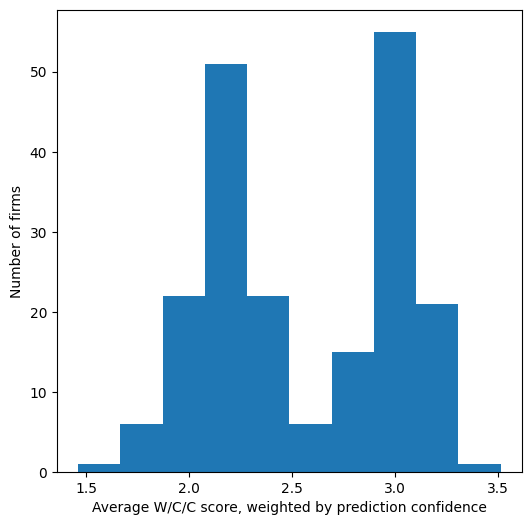

In [123]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.hist(client_weighted_average.to_numpy())
ax.set_xlabel('Average W/C/C score, weighted by prediction confidence')
ax.set_ylabel('Number of firms')

Text(0, 0.5, 'Average W/C/C score, weighted by prediction confidence')

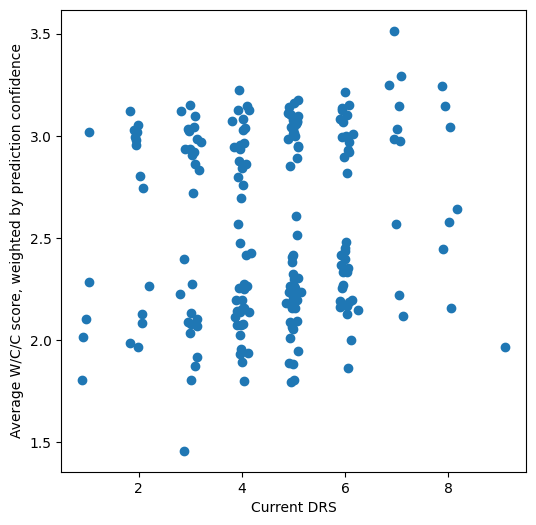

In [124]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
X = per_client_results[drs_col].to_numpy().reshape(-1,1)
Y = per_client_results['Weighted Average'].to_numpy().reshape(-1,1)
ax.scatter(rand_jitter(X), Y)
ax.set_xlabel('Current DRS')
ax.set_ylabel('Average W/C/C score, weighted by prediction confidence')
